# Мини-проект по написанию своего дерева и леса
На курсе мы просто учили деревья и лес используя готовые в sklearn классы. В этом ноутбуке я думаю написать свои деревья и леса для регрессии и классификации.

## 0. Импорты

In [29]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from natsort import natsorted
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV, cross_validate, KFold
from sklearn.metrics import classification_report
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print('Импорты подключены успешно')

kagglehub.login() 

Импорты подключены успешно


## 1. Выбор датасета для классификации
В общем мне интересно попробовать поработать с бигдатой. Хочу взять кредитную историю на каггле от альфа-банка. Там был контест. Основной целью является написание своего решающего дерева и случайного леса, по возможности также будут использованы и реализованы другие модели. Т.к. линейную и логистическую регрессию я уже делал, то не вижу ничего страшного использовать готовые из sklearn. Также мои модели будут сравнены с деревом и лесом из sklearn. Что касается svm, есть мысль также реализовать его. В целом хочется понять как выбирать модель. Т.к. бустинг я параллельно делаю, то не уверен, что здесь он будет.

In [30]:
# Download latest version
path = kagglehub.competition_download('alfa-bank-pd-credit-history')

path = os.path.join(path, 'data_for_competition')
path_to_train_data = os.path.join(path, 'train_data')
path_to_test_data = os.path.join(path, 'test_data')
path_to_train_target = os.path.join(path, 'train_target.csv')
path_to_test_target = os.path.join(path, 'test_target.csv')

print("Path to competition files:", path)
print("Path to competition train data files:", path_to_train_data)
print("Path to competition test data files:", path_to_test_data)
print("Path to competition train target files:", path_to_train_target)
print("Path to competition test target files:", path_to_test_target)

X_train_files = [os.path.join(path_to_train_data, f) for f in os.listdir(path_to_train_data)]
X_test_files = [os.path.join(path_to_test_data, f) for f in os.listdir(path_to_test_data)]

print(f"Найдено файлов: {len(X_train_files)}")
print(f"Найдено файлов: {len(X_test_files)}")

print("Сортирую")
X_train_files = natsorted(X_train_files)
X_test_files = natsorted(X_test_files)
print("Отсортировал")

#Короче это на компе ток можно делать из-за оперативки
#dfs = []
#for file_path in X_train_files:
#    print(f"Загружаю {file_path}")
#    df = pd.read_parquet(file_path)

y_train = pd.read_csv(path_to_train_target)
y_test = pd.read_csv(path_to_test_target)

print("Данные загружены")

Path to competition files: /home/dd/.cache/kagglehub/competitions/alfa-bank-pd-credit-history/data_for_competition
Path to competition train data files: /home/dd/.cache/kagglehub/competitions/alfa-bank-pd-credit-history/data_for_competition/train_data
Path to competition test data files: /home/dd/.cache/kagglehub/competitions/alfa-bank-pd-credit-history/data_for_competition/test_data
Path to competition train target files: /home/dd/.cache/kagglehub/competitions/alfa-bank-pd-credit-history/data_for_competition/train_target.csv
Path to competition test target files: /home/dd/.cache/kagglehub/competitions/alfa-bank-pd-credit-history/data_for_competition/test_target.csv
Найдено файлов: 12
Найдено файлов: 2
Сортирую
Отсортировал
Данные загружены


## 2. EDA
Смотрим на данные просто... подгрузим один датафрейм только

In [31]:
pd.set_option('display.max_columns', None)

X_train = pd.read_parquet(X_train_files[0])
X_test = pd.read_parquet(X_test_files)

print("Размер X train:", X_train.shape)
print("Размер X test:", X_test.shape)
print("Размер y train:", y_train.shape)
print("Размер y test:", y_test.shape)
display(X_train.head())
display(X_train.tail())
display(y_train.head())
display(y_train.tail())

Размер X train: (1974724, 61)
Размер X test: (4724601, 61)
Размер y train: (3000000, 2)
Размер y test: (500000, 1)


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,3,0,2,11,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,3,0,2,11,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,5,0,2,8,6,16,5,4,8,1,1,1,1,1,15,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,3,0,2,4,6,16,5,4,8,0,1,1,1,1,16,2,17,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,3,0,2,4,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
1974719,249998,4,1,9,14,8,10,11,8,4,2,0,2,4,6,16,5,4,8,1,1,1,1,1,11,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,0,1
1974720,249998,5,7,9,4,8,1,11,19,1,4,0,2,7,6,16,5,4,8,1,1,1,1,1,7,2,17,0,1,1,0,0,0,0,0,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,1,1
1974721,249999,1,9,0,10,8,10,11,16,2,3,0,2,7,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,0,1
1974722,249999,2,9,16,10,13,10,4,12,2,3,0,2,7,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,0,0
1974723,249999,3,9,9,6,1,0,4,16,2,4,0,2,2,6,16,5,4,8,1,1,1,1,1,5,2,17,0,1,1,0,0,0,0,0,0,0,0,0,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,0,0


,id,flag
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


,id,flag
2999995,2999995,0
2999996,2999996,0
2999997,2999997,0
2999998,2999998,0
2999999,2999999,0


In [32]:
display(X_train.describe())
display(X_train.info())

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
count,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1974724.0,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06
mean,1.259465e+05,6.537471e+00,9.271325e+00,8.330264e+00,8.299071e+00,8.309444e+00,6.991781e+00,8.337011e+00,9.740888e+00,2.399848e+00,3.012951e+00,0.0,2.012115e+00,4.595422e+00,5.979092e+00,1.587038e+01,5.000825e+00,3.999941e+00,8.001086e+00,9.049189e-01,8.316909e-01,9.587416e-01,9.786112e-01,9.793075e-01,1.393471e+01,2.173915e+00,1.558773e+01,7.113070e-01,9.433263e-01,8.361092e-01,1.857206e-01,3.843271e-01,5.195359e-01,6.493839e-01,7.956054e-01,9.293010e-01,1.118293e+00,1.258795e+00,1.375658e+00,1.485436e+00,1.628490e+00,2.745407e+00,1.898640e+00,1.994735e+00,2.050834e+00,2.095171e+00,2.135815e+00,2.174022e+00,2.217775e+00,2.252719e+00,3.283859e+00,2.313242e+00,2.343014e+00,2.376717e+00,3.576724e+00,1.027562e+00,2.694898e+00,3.353936e+00,1.002386e+00,1.721385e-01,2.239336e-01
std,7.226981e+04,5.121167e+00,5.773757e+00,4.593511e+00,5.245598e+00,4.464844e+00,5.184165e+00,4.233992e+00,5.799625e+00,1.376391e+00,6.838444e-01,0.0,3.348170e-01,3.121979e+00,3.459040e-01,1.196644e+00,5.565496e-02,1.323673e-02,8.129802e-02,2.933270e-01,3.741406e-01,1.988874e-01,1.446767e-01,1.423529e-01,4.335488e+00,8.238384e-01,4.151471e+00,4.531550e-01,2.312182e-01,3.701765e-01,6.533174e-01,9.325016e-01,1.080758e+00,1.188198e+00,1.283382e+00,1.351175e+00,1.419440e+00,1.452223e+00,1.469482e+00,1.476794e+00,1.473651e+00,1.460947e+00,1.428584e+00,1.399418e+00,1.379008e+00,1.361148e+00,1.343358e+00,1.325238e+00,1.302779e+00,1.283559e+00,1.265590e+00,1.247674e+00,1.228473e+00,1.205555e+00,1.035586e+00,2.767022e-01,4.891363e-01,1.057304e+00,5.909327e-02,3.775009e-01,4.168782e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.0,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.0000

<class 'pandas.DataFrame'>
RangeIndex: 1974724 entries, 0 to 1974723
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int64
 2   pre_since_opened               int64
 3   pre_since_confirmed            int64
 4   pre_pterm                      int64
 5   pre_fterm                      int64
 6   pre_till_pclose                int64
 7   pre_till_fclose                int64
 8   pre_loans_credit_limit         int64
 9   pre_loans_next_pay_summ        int64
 10  pre_loans_outstanding          int64
 11  pre_loans_total_overdue        int64
 12  pre_loans_max_overdue_sum      int64
 13  pre_loans_credit_cost_rate     int64
 14  pre_loans5                     int64
 15  pre_loans530                   int64
 16  pre_loans3060                  int64
 17  pre_loans6090                  int64
 18  pre_loans90                    int64
 19  is_zero_loa

None

Все значения числовые, еще и инты, энкодинг делать не нужно.

In [33]:
display(X_train.isnull().sum())
print(f"Всего нулевых значений: {sum(X_train.isnull().sum())}")

id                         0
rn                         0
pre_since_opened           0
pre_since_confirmed        0
pre_pterm                  0
                          ..
enc_loans_credit_status    0
enc_loans_credit_type      0
enc_loans_account_cur      0
pclose_flag                0
fclose_flag                0
Length: 61, dtype: int64

Всего нулевых значений: 0


Великолепно. У нас нет нулевых значений вообще. Значит с пропусками работать не надо.  
Сейчас будет обрезка y_train, потому что мне не нужен весь файл, только первые 250000 значений. (потом уберу)

Размер y: (250000, 2)


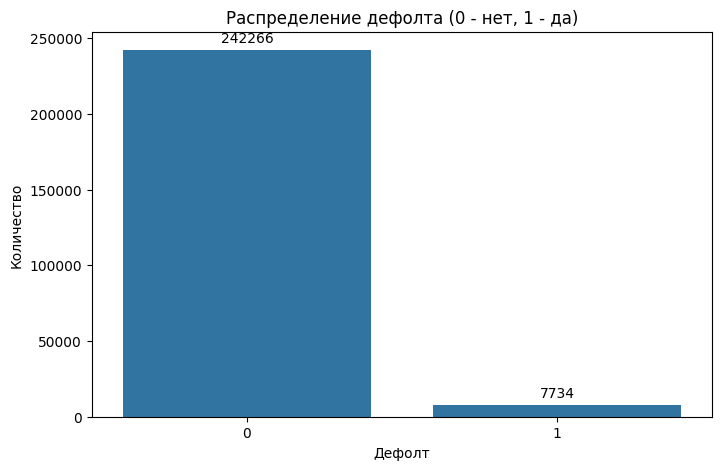

In [34]:
y_train = y_train[:250000]
print("Размер y:", y_train.shape)

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='flag', data=y_train)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Распределение дефолта (0 - нет, 1 - да)')
plt.xlabel('Дефолт')
plt.ylabel('Количество')
plt.show()

## 3. Feature engineering
Сначала удалим шумные данные. В нашем случае если отклонение меньше 1%, то мы считаем это шумом.

In [35]:
print("Размер X:", X_train.shape)
print("Удаляем шумные и константные данные")

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)
X_train_filtered = X_train[X_train.columns[selector.get_support()]]
X_test_filtered = X_test[X_test.columns[selector.get_support()]]

print("Удалили")
print("Размер X:", X_train_filtered.shape)

Размер X: (1974724, 61)
Удаляем шумные и константные данные


Удалили
Размер X: (1974724, 56)


Теперь нужно создать правила агрегации для наших данных. Далее в коде они будут описаны. Я хочу посмотреть на корреляцию признаков ещё.

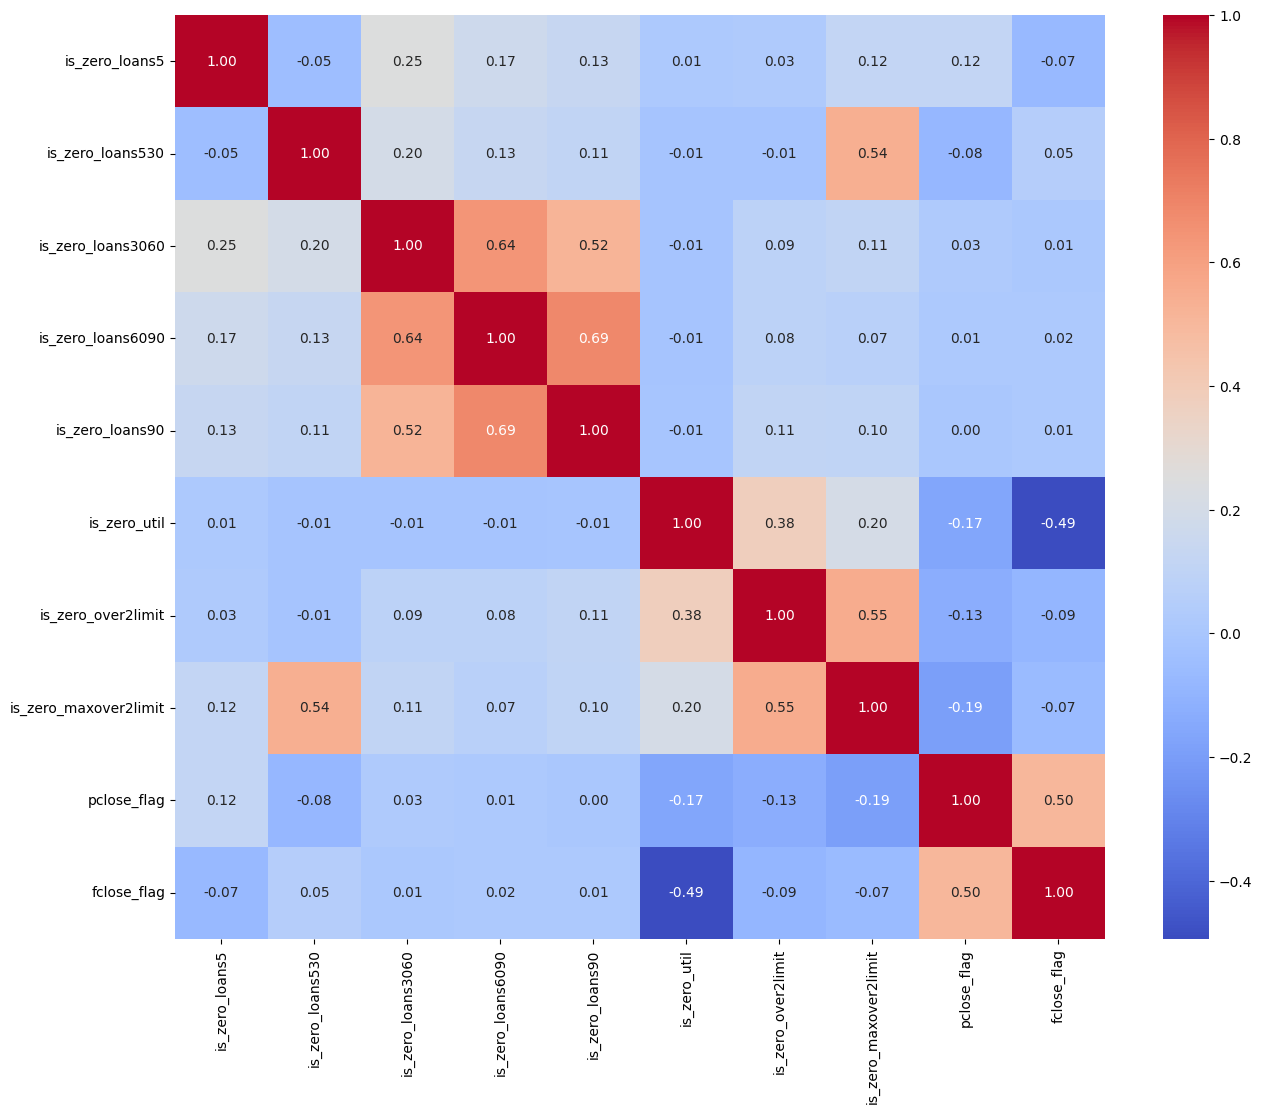

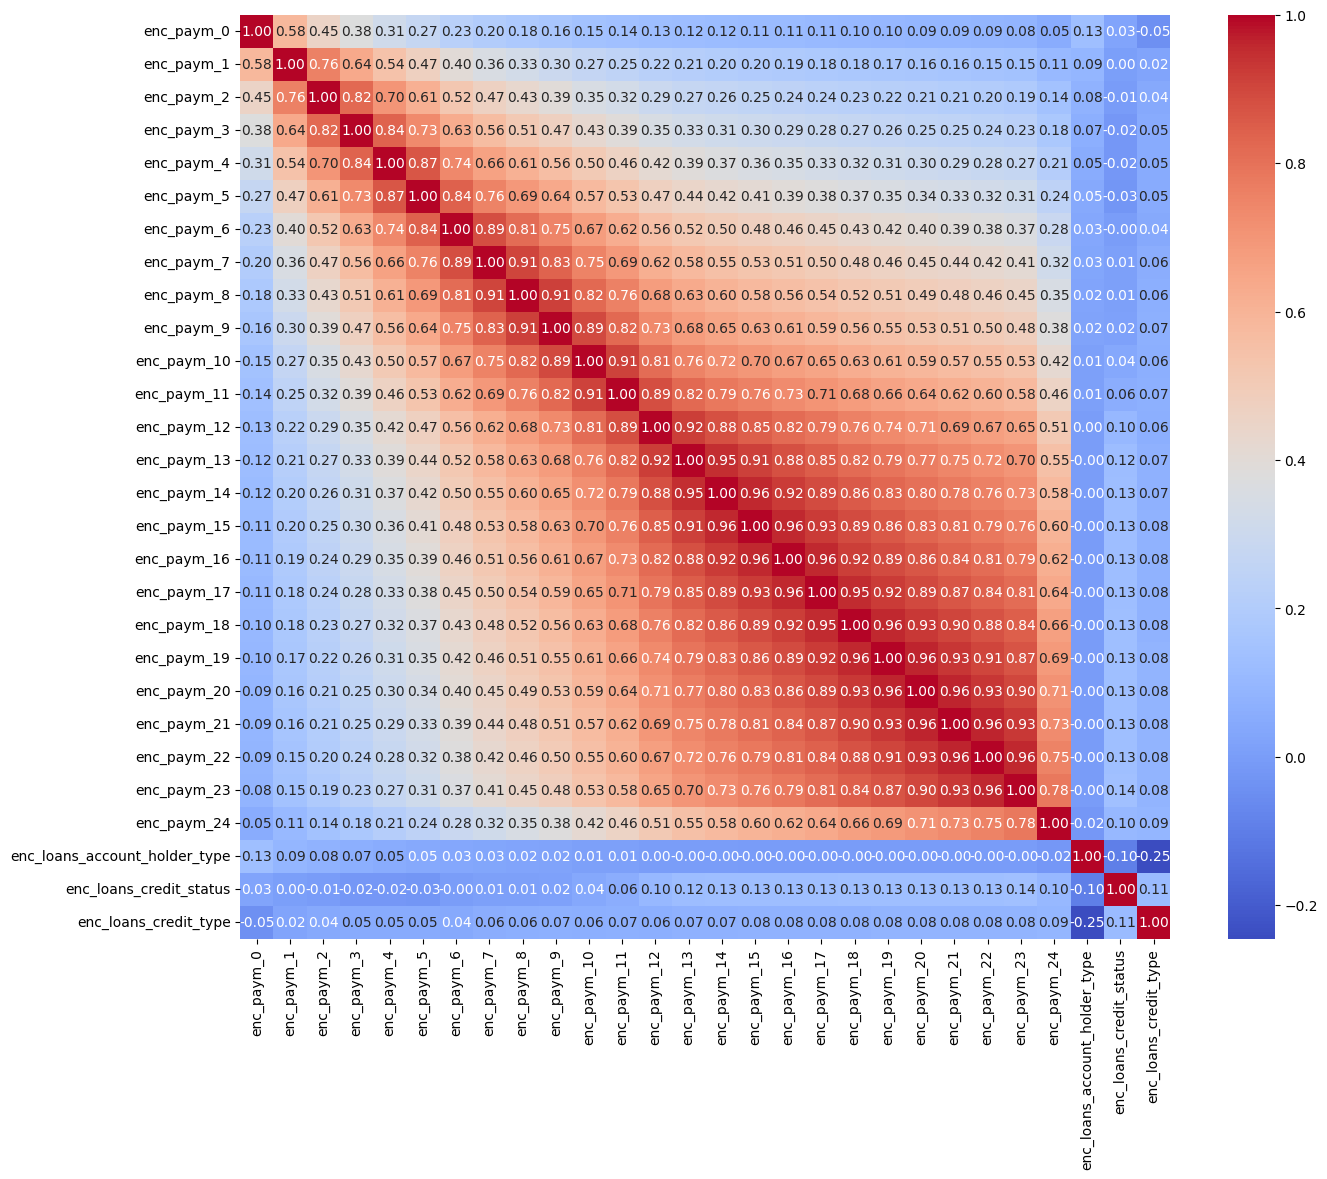

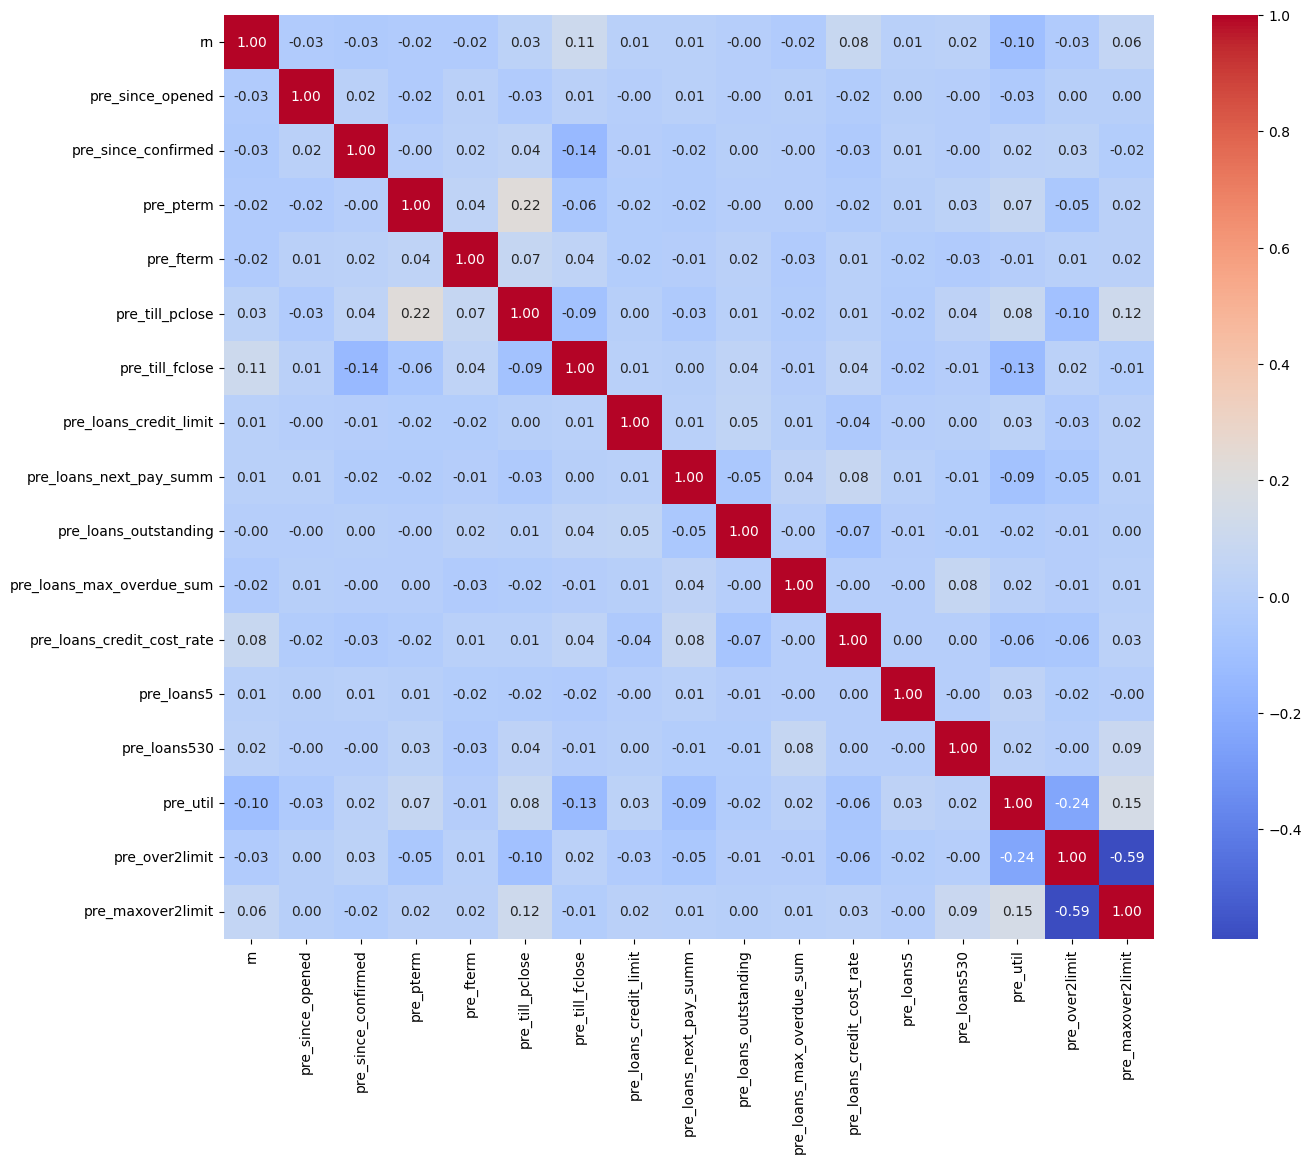

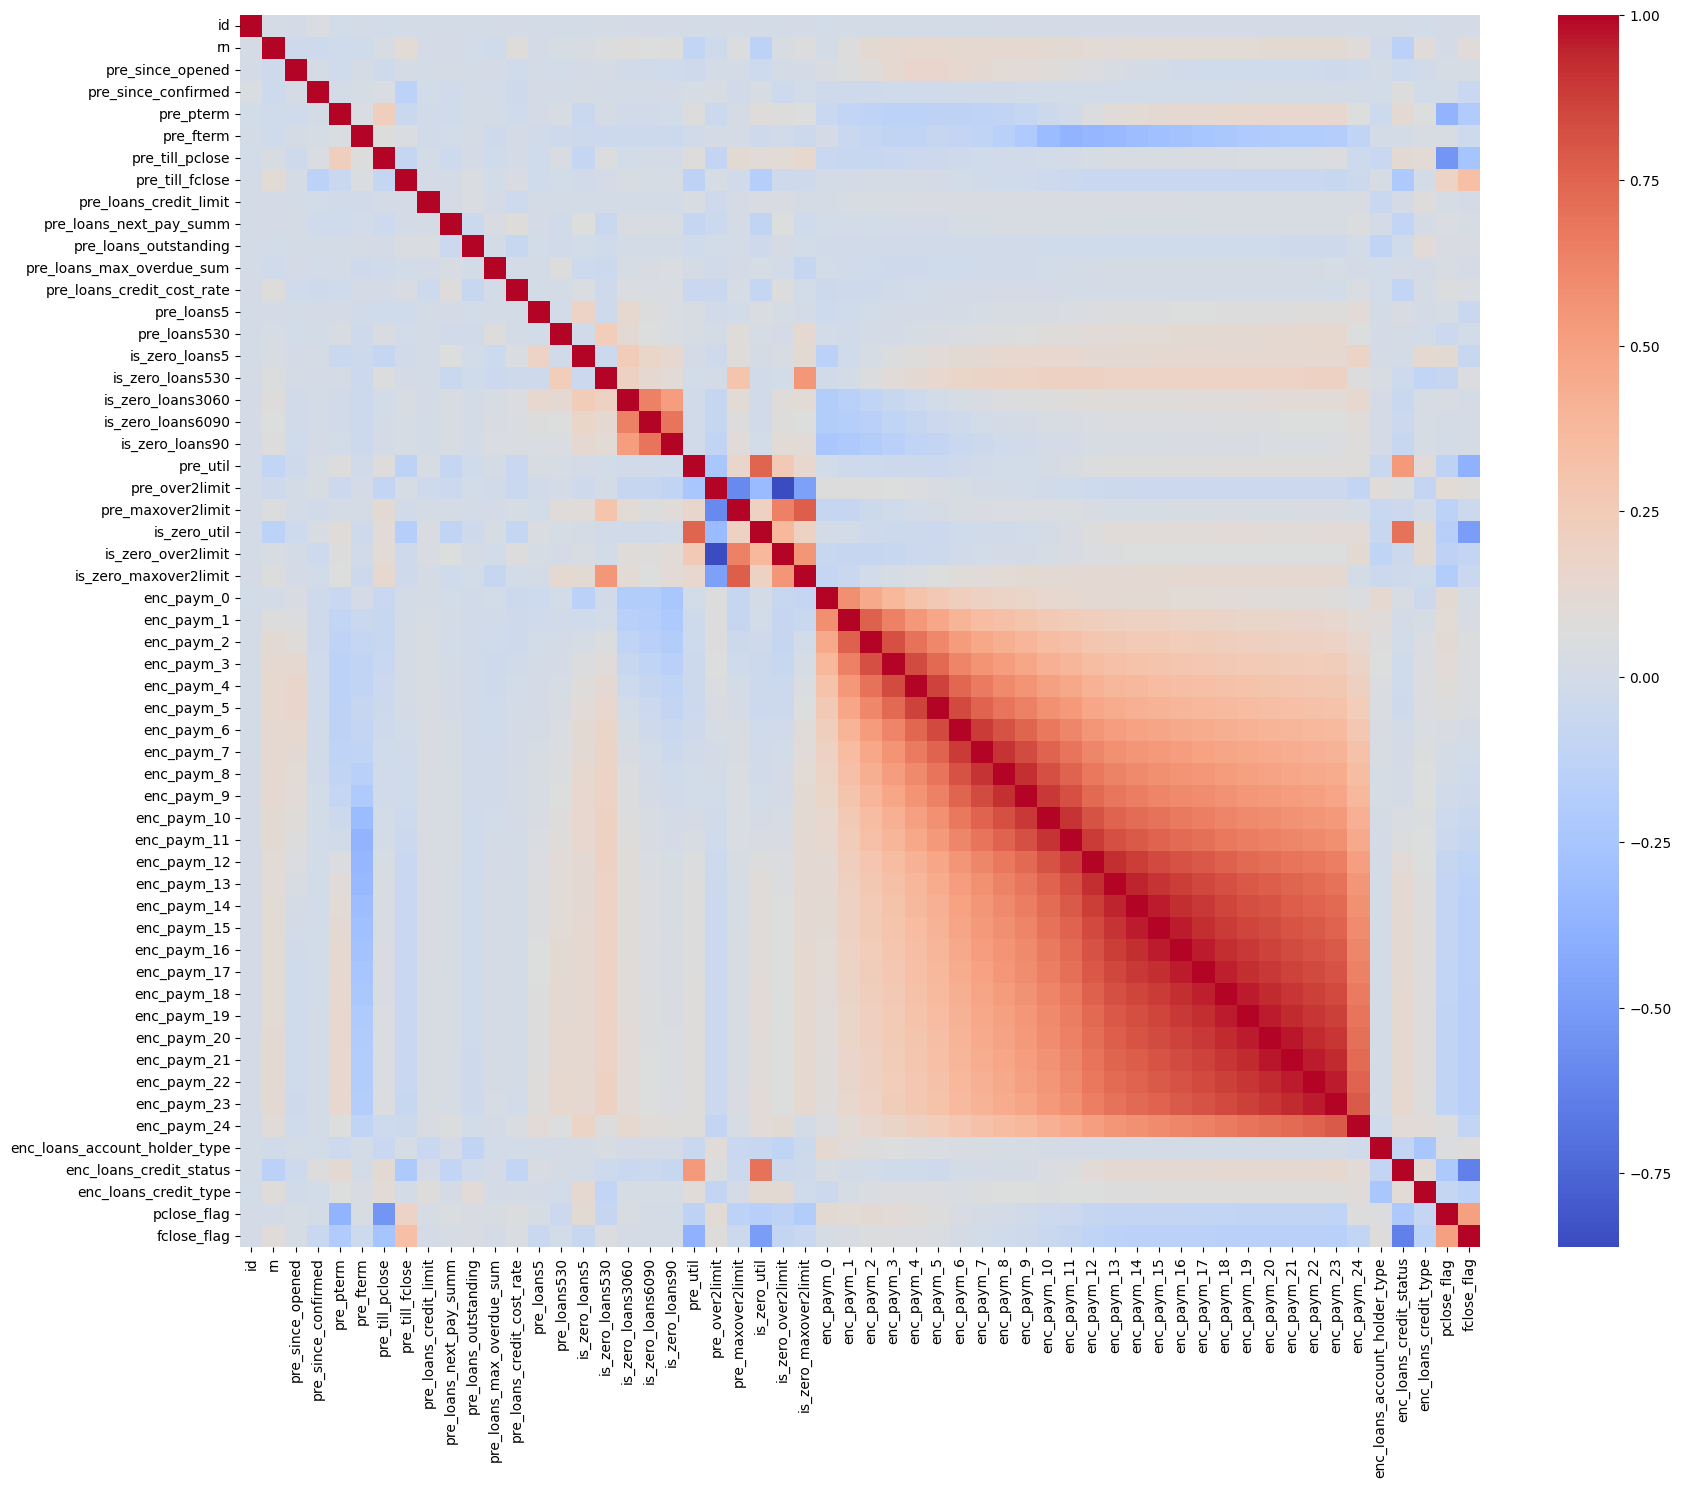

In [36]:
all_columns = X_train_filtered.columns.drop('id', 'rn')
is_columns = [column for column in all_columns if (column.startswith('is_') or column.endswith('_flag'))]
enc_columns = [column for column in all_columns if column.startswith('enc_')]
other_columns = [column for column in all_columns if column not in is_columns + enc_columns]

X_train_is_columns = X_train_filtered[is_columns]
X_train_enc_columns = X_train_filtered[enc_columns]
X_train_other_columns = X_train_filtered[other_columns]

plt.figure(figsize=(15, 12))
sns.heatmap(X_train_is_columns.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()
plt.figure(figsize=(15, 12))
sns.heatmap(X_train_enc_columns.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()
plt.figure(figsize=(15, 12))
sns.heatmap(X_train_other_columns.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()
plt.figure(figsize=(20, 16))
sns.heatmap(X_train_filtered.corr(), fmt=".2f", cmap='coolwarm')
plt.show()

Я очень хочу оставить только плату за 16 и 23 месяц какой-нибудь

In [37]:
enc_paym_columns = [column for column in all_columns if (column.startswith('enc_paym_') and not (column.endswith('16') or column.endswith('23')))]
X_train_filtered = X_train_filtered.drop(enc_paym_columns, axis=1)
display(X_train_filtered)

enc_columns = [column for column in all_columns if (column.startswith('enc_loans') or column.endswith('16') or column.endswith('23'))]
print(enc_columns)

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_16,enc_paym_23,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,3,2,11,6,16,1,1,1,1,1,16,2,17,1,1,1,3,3,1,3,4,0,0
1,0,2,18,9,14,14,12,12,0,3,3,2,11,6,16,1,1,1,1,1,16,2,17,1,1,1,0,0,1,3,4,0,0
2,0,3,18,9,4,8,1,11,11,0,5,2,8,6,16,1,1,1,1,1,15,2,17,0,1,1,0,0,1,2,3,1,1
3,0,4,4,1,9,12,16,7,12,2,3,2,4,6,16,0,1,1,1,1,16,2,17,1,1,1,3,3,1,3,1,0,0
4,0,5,5,12,15,2,11,12,10,2,3,2,4,6,16,1,1,1,1,1,16,2,17,1,1,1,3,3,1,3,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1974719,249998,4,1,9,14,8,10,11,8,4,2,2,4,6,16,1,1,1,1,1,11,2,17,0,1,1,3,3,1,2,3,0,1
1974720,249998,5,7,9,4,8,1,11,19,1,4,2,7,6,16,1,1,1,1,1,7,2,17,0,1,1,3,3,1,2,4,1,1
1974721,249999,1,9,0,10,8,10,11,16,2,3,2,7,6,16,1,1,1,1,1,16,2,17,1,1,1,3,3,1,2,3,0,1
1974722,249999,2,9,16,10,13,10,4,12,2,3,2,7,6,16,1,1,1,1,1,16,2,17,1,1,1,3,3,1,2,3,0,0


['enc_paym_16', 'enc_paym_23', 'enc_loans_account_holder_type', 'enc_loans_credit_status', 'enc_loans_credit_type']


Дропаем скоррелированные признаки

In [38]:
print("Формируем правила группировки")

agg_rules = {}

for col in is_columns:
    agg_rules[col] = ['mean', 'sum']
for col in enc_columns:
    agg_rules[col] = ['mean', 'max', 'last']
for col in other_columns:
    agg_rules[col] = ['mean', 'max']

print("Применяем правила")

X_train_grouped = X_train_filtered.groupby('id').agg(agg_rules)
X_test_grouped = X_test_filtered.groupby('id').agg(agg_rules)

print("Сгруппровали")

Формируем правила группировки
Применяем правила
Сгруппровали


Теперь посмотрим на наши данные собственно

In [39]:
print("Размер X:", X_train_grouped.shape)
display(X_train_grouped.head())
display(X_train_grouped.tail())

Размер X: (250000, 69)


is_zero_loans5     is_zero_loans530     is_zero_loans3060      \
             mean sum             mean sum              mean sum   
id                                                                 
0        0.900000   9         1.000000  10          1.000000  10   
1        0.857143  12         0.714286  10          0.857143  12   
2        1.000000   3         0.666667   2          0.666667   2   
3        1.000000  15         1.000000  15          1.000000  15   
4        1.000000   1         1.000000   1          1.000000   1   

   is_zero_loans6090     is_zero_loans90     is_zero_util      \
                mean sum            mean sum         mean sum   
id                                                              
0           1.000000  10        1.000000  10     0.600000   6   
1           0.857143  12        0.785714  11     0.714286  10   
2           0.666667   2        1.000000   3     0.333333   1   
3           1.000000  15        1.000000  15     0.533333   8   
4           1.000000   1        1.000000   1     1.000000   1   

   is_zero_over2limit     is_zero_maxover2limit     pclose_flag      \
                 mean sum                  mean sum        mean sum   
id                                                                    
0            0.900000   9              0.900000   9    0.100000   1   
1            0.857143  12              0.785714  11    0.071429   1   
2            1.000000   3              0.666667   2    0.666667   2   
3            0.933333  14              0.933333  14    0.333333   5   
4            1.000000   1              1.000000   1    1.000000   1   

   fclose_flag     enc_paym_16          enc_paym_23           \
          mean sum        mean max last        mean max last   
id                                                             
0     0.200000   2    2.100000   3    3    2.400000   3    3   
1     0.142857   2    2.142857   3    3    2.357143   3    3   
2     0.666667   2    2.666667   3    3    2.333333   3    3   
3     0.400000   6    1.600000   3    3    1.600000   3    3   
4     1.000000   1    3.000000   3    3    3.000000   3    3   

   enc_loans_account_holder_type          enc_loans_credit_status           \
                            mean max last                    mean max last   
id                                                                           
0                            1.0   1    1                2.600000   3    2   
1                            1.0   1    1                2.714286   3    2   
2                            1.0   1    1                2.333333   3    2   
3                            1.0   1    1                2.533333   3    2   
4                            1.0   1    1                2.000000   2    2   

   enc_loans_credit_type            rn     pre_since_opened      \
                    mean max last mean max             mean max   
id                                                                
0               3.500000   4    4  5.5  10         8.100000  18   
1               3.142857   4    3  7.5  14        11.428571  18   
2               3.333333   4    3  2.0   3         8.333333  13   
3               3.600000   5    4  8.0  15         7.000000  18   
4               3.000000   3    3  1.0   1        12.000000  12   

   pre_since_confirmed     pre_pterm     pre_fterm     pre_till_pclose      \
                  mean max      mean max      mean max            mean max   
id                                                                           
0             7.600000  12  7.100000  15  7.500000  14       11.400000  16   
1             7.642857  14  6.642857  15  7.928571  16       10.071429  15   
2            10.666667  14  7.000000  13  6.000000   8        5.000000  13   
3             7.333333  16  7.600000  16  7.800000  16        5.200000  16   
4             9.000000   9  4.000000   4  8.000000   8        1.000000   1   

   pre_till_fclose     pre_loans_credit_limit     pre_loans_next_pay

is_zero_loans5     is_zero_loans530     is_zero_loans3060      \
                 mean sum             mean sum              mean sum   
id                                                                     
249995       1.000000  13         0.923077  12               1.0  13   
249996       0.826087  19         0.826087  19               1.0  23   
249997       1.000000   7         0.714286   5               1.0   7   
249998       1.000000   5         0.800000   4               1.0   5   
249999       1.000000   3         1.000000   3               1.0   3   

       is_zero_loans6090     is_zero_loans90     is_zero_util      \
                    mean sum            mean sum         mean sum   
id                                                                  
249995               1.0  13             1.0  13     0.692308   9   
249996               1.0  23             1.0  23     0.782609  18   
249997               1.0   7             1.0   7     1.000000   7   
249998               0.8   4             0.6   3     0.200000   1   
249999               1.0   3             1.0   3     0.666667   2   

       is_zero_over2limit     is_zero_maxover2limit     pclose_flag      \
                     mean sum                  mean sum        mean sum   
id                                                                        
249995           1.000000  13              0.923077  12    0.076923   1   
249996           0.869565  20              0.739130  17    0.217391   5   
249997           1.000000   7              0.857143   6    0.142857   1   
249998           0.600000   3              0.600000   3    0.400000   2   
249999           1.000000   3              1.000000   3    0.000000   0   

       fclose_flag     enc_paym_16          enc_paym_23           \
              mean sum        mean max last        mean max last   
id                                                                 
249995    0.230769   3    3.000000   3    3    3.000000   3    3   
249996    0.217391   5    2.478261   3    3    2.608696   3    3   
249997    0.285714   2    1.285714   3    3    1.285714   3    3   
249998    0.600000   3    3.000000   3    3    3.000000   3    3   
249999    0.333333   1    3.000000   3    3    3.000000   3    3   

       enc_loans_account_holder_type          enc_loans_credit_status      \
                                mean max last                    mean max   
id                                                                          
249995                           1.0   1    1                2.692308   3   
249996                           1.0   1    1                2.782609   3   
249997                           1.0   1    1                2.857143   4   
249998                           1.0   1    1                2.600000   4   
249999                           1.0   1    1                2.000000   2   

            enc_loans_credit_type             rn     pre_since_opened      \
       last                  mean max last  mean max             mean max   
id                                                                          
249995    2              3.846154   5    4   7.0  13         7.615385  18   
249996    2              3.304348   5    4  12.0  23         9.217391  19   
249997    2              2.571429   4    3   4.0   7         6.857143  14   
249998    2              3.000000   4    4   3.0   5         6.800000  15   
249999    2              3.000000   3    3   2.0   3         9.000000   9   

       pre_since_confirmed      pre_pterm      pre_fterm     pre_till_pclose  \
                      mean max       mean max       mean max            mean   
id                                                                             
249995            7.538462  14  10.230769  16   4.846154   9        5.769231   
249996            9.782609  17   8.652174  17   7.869565  15        7.869565   
249997            5.142857   6  10.428571  17  12.571429  16        7.428571   
249998           

In [40]:
final_columns = [f"{col[0]}_{col[1]}" for col in X_train_grouped.columns]
X_train_final = X_train_grouped
X_test_final = X_test_grouped
X_train_final.columns = final_columns
X_test_final.columns = final_columns
display(X_train_final)
print(X_train_final.columns)

,is_zero_loans5_mean,is_zero_loans5_sum,is_zero_loans530_mean,is_zero_loans530_sum,is_zero_loans3060_mean,is_zero_loans3060_sum,is_zero_loans6090_mean,is_zero_loans6090_sum,is_zero_loans90_mean,is_zero_loans90_sum,is_zero_util_mean,is_zero_util_sum,is_zero_over2limit_mean,is_zero_over2limit_sum,is_zero_maxover2limit_mean,is_zero_maxover2limit_sum,pclose_flag_mean,pclose_flag_sum,fclose_flag_mean,fclose_flag_sum,enc_paym_16_mean,enc_paym_16_max,enc_paym_16_last,enc_paym_23_mean,enc_paym_23_max,enc_paym_23_last,enc_loans_account_holder_type_mean,enc_loans_account_holder_type_max,enc_loans_account_holder_type_last,enc_loans_credit_status_mean,enc_loans_credit_status_max,enc_loans_credit_status_last,enc_loans_credit_type_mean,enc_loans_credit_type_max,enc_loans_credit_type_last,rn_mean,rn_max,pre_since_opened_mean,pre_since_opened_max,pre_since_confirmed_mean,pre_since_confirmed_max,pre_pterm_mean,pre_pterm_max,pre_fterm_mean,pre_fterm_max,pre_till_pclose_mean,pre_till_pclose_max,pre_till_fclose_mean,pre_till_fclose_max,pre_loans_credit_limit_mean,pre_loans_credit_limit_max,pre_loans_next_pay_summ_mean,pre_loans_next_pay_summ_max,pre_loans_outstanding_mean,pre_loans_outstanding_max,pre_loans_max_overdue_sum_mean,pre_loans_max_overdue_sum_max,pre_loans_credit_cost_rate_mean,pre_loans_credit_cost_rate_max,pre_loans5_mean,pre_loans5_max,pre_loans530_mean,pre_loans530_max,pre_util_mean,pre_util_max,pre_over2limit_mean,pre_over2limit_max,pre_maxover2limit_mean,pre_maxover2limit_max
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.900000,9,1.000000,10,1.000000,10,1.000000,10,1.000000,10,0.600000,6,0.900000,9,0.900000,9,0.100000,1,0.200000,2,2.100000,3,3,2.400000,3,3,1.0,1,1,2.600000,3,2,3.500000,4,4,5.5,10,8.100000,18,7.600000,12,7.100000,15,7.500000,14,11.400000,16,10.700000,14,9.600000,16,3.100000,5,2.900000,5,2.000000,2,8.000000,13,6.0,6,16.000000,16,13.600000,16,2.300000,5,15.700000,17
1,0.857143,12,0.714286,10,0.857143,12,0.857143,12,0.785714,11,0.714286,10,0.857143,12,0.785714,11,0.071429,1,0.142857,2,2.142857,3,3,2.357143,3,3,1.0,1,1,2.714286,3,2,3.142857,4,3,7.5,14,11.428571,18,7.642857,14,6.642857,15,7.928571,16,10.071429,15,7.000000,15,8.142857,19,2.142857,5,2.928571,4,1.928571,3,3.714286,7,6.0,6,16.000000,16,12.214286,16,2.428571,10,15.857143,17
2,1.000000,3,0.666667,2,0.666667,2,0.666667,2,1.000000,3,0.333333,1,1.000000,3,0.666667,2,0.666667,2,0.666667,2,2.666667,3,3,2.333333,3,3,1.0,1,1,2.333333,3,2,3.333333,4,3,2.0,3,8.333333,13,10.666667,14,7.000000,13,6.000000,8,5.000000,13,9.000000,11,1.666667,3,1.333333,2,3.000000,4,1.666667,2,4.000000,5,6.0,6,11.333333,16,8.333333,16,2.000000,2,15.000000,17
3,1.000000,15,1.000000,15,1.000000,15,1.000000,15,1.000000,15,0.533333,8,0.933333,14,0.933333,14,0.333333,5,0.400000,6,1.600000,3,3,1.600000,3,3,1.0,1,1,2.533333,3,2,3.600000,5,4,8.0,15,7.000000,18,7.333333,16,7.600000,16,7.800000,16,5.200000,16,8.133333,12,9.866667,18,2.600000,6,3.266667,5,2.000000,2,4.466667,9,6.0,6,16.000000,16,12.200000,18,2.200000,5,16.133333,17
4,1.000000,1,1.000000,1,1.000000,1,1.000000,1,1.000000,1,1.000000,1,1.000000,1,1.000000,1,1.000000,1,1.000000,1,3.000000,3,3,3.000000,3,3,1.0,1,1,2.000000,2,2,3.000000,3,3,1.0,1,12.000000,12,9.000000,9,4.000000,4,8.000000,8,1.000000,1,11.000000,11,12.000000,12,1.000000,1,3.000000,3,2.000000,2,0.000000,0,6.0,6,16.000000,16,16.000000,16,2.000000,2,17.000000,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,1.000000,13,0.923077,12,1.000000,13,1.000000,13,1.000000,13,0.692308,9,1.000000,13,0.923077,12,0.076923,1,0.230769,3,3.000000,3,3,3.000000,3,3,1.0,1,1,2.692308,3,2,3.846154,5,4,7.0,13,7.615385,18,7.538462,14,10.230769,16,4.846154,9,5.769231,13,7.230769,12,9.076923,19,2.384615,6,3.076923,4,2.076923,3,4.61538

Index(['is_zero_loans5_mean', 'is_zero_loans5_sum', 'is_zero_loans530_mean',
       'is_zero_loans530_sum', 'is_zero_loans3060_mean',
       'is_zero_loans3060_sum', 'is_zero_loans6090_mean',
       'is_zero_loans6090_sum', 'is_zero_loans90_mean', 'is_zero_loans90_sum',
       'is_zero_util_mean', 'is_zero_util_sum', 'is_zero_over2limit_mean',
       'is_zero_over2limit_sum', 'is_zero_maxover2limit_mean',
       'is_zero_maxover2limit_sum', 'pclose_flag_mean', 'pclose_flag_sum',
       'fclose_flag_mean', 'fclose_flag_sum', 'enc_paym_16_mean',
       'enc_paym_16_max', 'enc_paym_16_last', 'enc_paym_23_mean',
       'enc_paym_23_max', 'enc_paym_23_last',
       'enc_loans_account_holder_type_mean',
       'enc_loans_account_holder_type_max',
       'enc_loans_account_holder_type_last', 'enc_loans_credit_status_mean',
       'enc_loans_credit_status_max', 'enc_loans_credit_status_last',
       'enc_loans_credit_type_mean', 'enc_loans_credit_type_max',
       'enc_loans_credit_type_last',

## 4. Делаем случайный лес сначала
Я чет не думал, что датасет будет таким огромным, и он не совсем под обучение подходит, ну да ладно. Просто сначала сделаем простейшее дерево и посмотрим как оно справится.

In [41]:
X_train_final = X_train_final.reset_index(drop=True)
y_train = y_train.drop('id', axis=1)
X_test_final = X_test_final.reset_index(drop=True)
y_test = y_test.drop('id', axis=1)

Нужно отсеивать признаки, которые создают шум

In [61]:
custom_weights = {0: 5, 1: 1}

sk_rf_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('under', RandomUnderSampler(sampling_strategy=1.0)),
    ('sk_rf', RandomForestClassifier(n_estimators=300, n_jobs=-1, class_weight='balanced', max_depth=10))
])

sk_rf_pipe.fit(X_train_final, y_train.values.ravel())
sk_rf_pipe_feature_importances = sk_rf_pipe.named_steps['sk_rf'].feature_importances_
feature_importances = pd.DataFrame(index=X_train_final.columns)
feature_importances['rf'] = sk_rf_pipe_feature_importances
feature_importances = feature_importances.sort_values(by='rf', ascending=False)
display(feature_importances.head(20))

,rf
enc_paym_16_mean,0.055206
is_zero_loans3060_mean,0.052090
is_zero_loans530_mean,0.050493
enc_paym_23_mean,0.042037
is_zero_loans6090_mean,0.033422
pre_util_mean,0.032251
enc_loans_credit_type_mean,0.031181
is_zero_loans90_mean,0.027996
pre_maxover2limit_mean,0.026539
is_zero_maxover2limit_mean,0.026297


In [62]:
scoring = ['f1', 'roc_auc', 'precision', 'recall']
kf = KFold(n_splits=5, shuffle=True, random_state=42)
sk_rf_pipe_score = cross_validate(sk_rf_pipe, X_train_final, y_train.values.ravel(), n_jobs=-1, cv=kf, scoring=scoring)
display(sk_rf_pipe_score)

{'fit_time': array([2.9652884 , 2.87997103, 2.63290334, 2.14683795, 2.51226521]),
 'score_time': array([1.23371148, 1.25721908, 1.55643916, 1.64215827, 1.42554426]),
 'test_f1': array([0.11122426, 0.11054761, 0.12005366, 0.11901291, 0.11601006]),
 'test_roc_auc': array([0.72637559, 0.72509016, 0.7362466 , 0.74222614, 0.73788494]),
 'test_precision': array([0.06081039, 0.06040227, 0.06592192, 0.06511848, 0.06345519]),
 'test_recall': array([0.65056254, 0.65100671, 0.67125   , 0.69047619, 0.67534157])}

In [63]:
X_train_top_20 = X_train_final[feature_importances.head(10).index.to_list()]
X_test_top_20 = X_test_final[feature_importances.head(10).index.to_list()]
display(X_train_top_20)

,enc_paym_16_mean,is_zero_loans3060_mean,is_zero_loans530_mean,enc_paym_23_mean,is_zero_loans6090_mean,pre_util_mean,enc_loans_credit_type_mean,is_zero_loans90_mean,pre_maxover2limit_mean,is_zero_maxover2limit_mean
0,2.100000,1.000000,1.000000,2.400000,1.000000,13.600000,3.500000,1.000000,15.700000,0.900000
1,2.142857,0.857143,0.714286,2.357143,0.857143,12.214286,3.142857,0.785714,15.857143,0.785714
2,2.666667,0.666667,0.666667,2.333333,0.666667,8.333333,3.333333,1.000000,15.000000,0.666667
3,1.600000,1.000000,1.000000,1.600000,1.000000,12.200000,3.600000,1.000000,16.133333,0.933333
4,3.000000,1.000000,1.000000,3.000000,1.000000,16.000000,3.000000,1.000000,17.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
249995,3.000000,1.000000,0.923077,3.000000,1.000000,13.384615,3.846154,1.000000,15.692308,0.923077
249996,2.478261,1.000000,0.826087,2.608696,1.000000,14.347826,3.304348,1.000000,15.304348,0.739130
249997,1.285714,1.000000,0.714286,1.285714,1.000000,16.000000,2.571429,1.000000,17.000000,0.857143
249998,3.000000,1.000000,0.800000,3.000000,0.800000,12.200000,3.000000,0.600000,13.400000,0.600000


In [64]:
sk_rf_pipe_score = cross_validate(sk_rf_pipe, X_train_top_20, y_train.values.ravel(), n_jobs=-1, cv=kf, scoring=scoring)
display(sk_rf_pipe_score)

{'fit_time': array([1.40059447, 1.08212256, 1.06090164, 1.30288863, 1.17482519]),
 'score_time': array([0.76654172, 1.00413752, 1.07670116, 0.85595369, 0.97959208]),
 'test_f1': array([0.0998749 , 0.10154924, 0.10799775, 0.11309087, 0.11040877]),
 'test_roc_auc': array([0.69905872, 0.70843744, 0.71546296, 0.72103404, 0.72372167]),
 'test_precision': array([0.05420698, 0.05513308, 0.05880064, 0.06170651, 0.06006763]),
 'test_recall': array([0.63401721, 0.64228188, 0.66125   , 0.67606516, 0.68184776])}